# SCOS Noise Visualizer — Opening One Measurement and Seeing All the Noise

This notebook opens **one example SCOS measurement** and walks through everything that
contributes to the measured speckle contrast, using the functions in `scos_calculation.py`
directly:

1. The raw data (mean frame, background/dark image, ROI mask)
2. The **dark noise** map (`darkVarPerWindow`, from `calculate_dark_noise`)
3. A **per-pixel noise budget** for one example frame — raw variance, shot-noise variance,
   dark-noise variance, and the corrected (residual) variance, side by side
4. The full `SCOS_Calculation` run across all frames (`K2_raw`, `K2_corrected`, `BFi`)
5. A **decomposition over time**: how much of `K2_raw` at every frame comes from dark
   noise vs. shot noise vs. the corrected signal
6. A frequency-domain check (`find_fft_peak`) for whether there's a real pulsatile/flow
   signal sitting above the noise floor

This is different from `scos_results_explorer.ipynb`, which browses *already-processed*
results saved by `scos_analysis.py`. This notebook instead opens **one raw measurement**
and recomputes everything live, so you can see where the noise actually comes from.

If no real measurement is found at `MEASUREMENT_DIR` below, the notebook falls back to a
small synthetic example (simulated speckle + shot noise + a ~1.2 Hz pulsatile flow signal)
so the whole notebook still runs end-to-end as a demo.

In [1]:
# 1. Imports
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
from scipy.ndimage import uniform_filter

# Folder containing scos_calculation.py (edit if it lives somewhere else)
SCOS_CODE_DIR = Path(".")
sys.path.insert(0, str(SCOS_CODE_DIR))

from scos_calculation import (
    SCOS_Calculation,
    SCOS_Calculation_CMOS,
    calculate_dark_noise,
    find_mask,
    find_fft_peak,
    theoretical_gain,
)

plt.rcParams["figure.dpi"] = 100

## 1. Point to an example measurement

`scos_analysis.py` expects each measurement folder (a `SCOS_Scan_*` offset folder, or a
`ref-*/SCOS_Single_*` folder) to contain:

| File | Contents |
|---|---|
| `image_data.npy` | raw frames, shape `(H, W, n_frames)` (or `(n_offsets, H, W, n_frames)` for a gated scan) |
| `roi_mask.npy` | boolean ROI mask, shape `(H, W)` — optional, auto-detected with `find_mask` if missing |
| `backgroundImg.npy` | mean dark frame, shape `(H, W)` — optional if `dark_frames.npy` is present instead |
| `darkVarPerWindow.npy` | windowed dark-noise variance, shape `(H, W)` — same |
| `dark_frames.npy` | raw dark frames, shape `(H, W, n_dark_frames)` — used to *compute* the two files above via `calculate_dark_noise` if they aren't saved directly |
| `metadata.json` | `frame_rate`, `gain`, `bit_depth`, `is_pileup_correction`, `black_level` (optional, default 0) |

Set `MEASUREMENT_DIR` below to one such folder. `GATE_INDEX` only matters if
`image_data.npy` is 4D (a gated scan with multiple offsets).

In [2]:
# 2. Set the measurement to open
MEASUREMENT_DIR = Path(r"E:\Shira_TZ_ISCOS\26-04-2026 1cm Gated +ISCOS\ref-1 -30%\SCOS_Single_1777209347")  # <-- point this at your data
GATE_INDEX = 0  # only used if image_data.npy is 4D (gated scan)


def _load_npy(folder, name, allow_none=True):
    p = folder / name
    if p.exists():
        return np.load(p, allow_pickle=True)
    if allow_none:
        return None
    raise FileNotFoundError(p)


def _ensure_float_array(arr):
    '''Some saved .npy files end up with dtype=object (e.g. saved via
    np.array(..., dtype=object) upstream) even though every element is a plain
    numeric array of the same shape. matplotlib/scipy can't work with dtype=object,
    so coerce it to a normal float array here.'''
    if arr is None:
        return None
    arr = np.asarray(arr)
    if arr.dtype == object:
        try:
            arr = arr.astype(float)
        except (TypeError, ValueError):
            arr = np.stack([np.asarray(a, dtype=float) for a in arr])
    else:
        arr = arr.astype(float, copy=False)
    return arr


def _ensure_bool_array(arr):
    if arr is None:
        return None
    arr = np.asarray(arr)
    if arr.dtype == object:
        arr = arr.astype(bool)
    return arr.astype(bool, copy=False)


def make_synthetic_measurement(H=64, W=64, n_frames=300, n_dark_frames=200,
                                frame_rate=100.0, nBits=8, black_level=2.0,
                                pulse_hz=1.2, seed=0):
    '''Small synthetic SPAD-style measurement: a Gaussian illumination spot, Poisson
    shot noise, and a sinusoidal flow/pulsatile modulation of the speckle contrast --
    used only when MEASUREMENT_DIR has no real data, so the notebook still runs.'''
    rng = np.random.default_rng(seed)
    N_max = 2 ** nBits - 1

    yy, xx = np.mgrid[0:H, 0:W]
    cy, cx = H / 2, W / 2
    r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    beam = np.exp(-(r ** 2) / (2 * (min(H, W) / 3) ** 2))

    dc_level = np.clip(black_level + rng.normal(0, 0.3, size=(H, W)), 0, None)
    dark_frames = rng.poisson(np.repeat(dc_level[:, :, None], n_dark_frames, axis=2)).astype(float)

    t = np.arange(n_frames) / frame_rate
    flow_mod = 1.0 + 0.15 * np.sin(2 * np.pi * pulse_hz * t)

    base_signal_level = 40.0
    frames = np.zeros((H, W, n_frames), dtype=float)
    for i in range(n_frames):
        speckle_contrast = 0.35 / np.sqrt(flow_mod[i])
        local_speckle = np.clip(rng.normal(1.0, speckle_contrast, size=(H, W)), 0, None)
        ideal = black_level + base_signal_level * beam * local_speckle
        frames[:, :, i] = rng.poisson(np.clip(ideal, 0, None))
    frames = np.clip(frames, 0, N_max)

    mask = beam > 0.15
    metadata = dict(frame_rate=frame_rate, gain=1.0, bit_depth=nBits,
                     is_pileup_correction=False, black_level=black_level)
    return frames, dark_frames, mask, metadata


def load_measurement(measurement_dir, gate_index=0):
    measurement_dir = Path(measurement_dir)
    image_data = _load_npy(measurement_dir, "image_data.npy")

    if image_data is not None:
        image_data = _ensure_float_array(image_data)
        if image_data.ndim == 4:
            image_data = image_data[gate_index]

        mask = _ensure_bool_array(_load_npy(measurement_dir, "roi_mask.npy"))
        backgroundImg = _ensure_float_array(_load_npy(measurement_dir, "backgroundImg.npy"))
        darkVarPerWindow = _ensure_float_array(_load_npy(measurement_dir, "darkVarPerWindow.npy"))
        dark_frames = _ensure_float_array(_load_npy(measurement_dir, "dark_frames.npy"))

        if backgroundImg is None or darkVarPerWindow is None:
            if dark_frames is None:
                raise FileNotFoundError(
                    "Need either (backgroundImg.npy & darkVarPerWindow.npy) or "
                    "dark_frames.npy to compute dark noise."
                )
            backgroundImg, darkVarPerWindow = calculate_dark_noise(dark_frames, window_size=7)

        meta_path = measurement_dir / "metadata.json"
        metadata = json.load(open(meta_path)) if meta_path.exists() else {}
        metadata.setdefault("frame_rate", 100.0)
        metadata.setdefault("gain", 1.0)
        metadata.setdefault("bit_depth", 8)
        metadata.setdefault("is_pileup_correction", False)
        metadata.setdefault("black_level", 0)

        if mask is None:
            mask = find_mask(np.mean(image_data, axis=2))

        return dict(image_data=image_data, mask=mask, backgroundImg=backgroundImg,
                    darkVarPerWindow=darkVarPerWindow, metadata=metadata, is_synthetic=False)

    print(f"[demo] No image_data.npy found under '{measurement_dir}' -> "
          f"using a synthetic example measurement instead. "
          f"Set MEASUREMENT_DIR to a real folder to use your own data.")
    image_data, dark_frames, mask, metadata = make_synthetic_measurement()
    backgroundImg, darkVarPerWindow = calculate_dark_noise(dark_frames, window_size=7)
    return dict(image_data=image_data, mask=mask, backgroundImg=backgroundImg,
                darkVarPerWindow=darkVarPerWindow, metadata=metadata, is_synthetic=True)


meas = load_measurement(MEASUREMENT_DIR, GATE_INDEX)
image_data = meas["image_data"]
mask = meas["mask"]
backgroundImg = meas["backgroundImg"]
darkVarPerWindow = meas["darkVarPerWindow"]
metadata = meas["metadata"]




print(f"image_data: {image_data.shape}  (H, W, n_frames)")
print(f"mask: {mask.sum()} / {mask.size} pixels in ROI")
print(f"metadata: {metadata}")

# --- Keep only the half of the sensor that was actually illuminated ---
HALF_AXIS = "H"      # "W" to cut left/right, "H" to cut top/bottom
HALF_SIDE = "top"   # "left"/"top" keeps the first half, "right"/"bottom" keeps the second half


H, W = image_data.shape[0], image_data.shape[1]

if HALF_AXIS == "W":
    mid = W // 2
    sl = slice(0, mid) if HALF_SIDE == "left" else slice(mid, W)
    image_data = image_data[:, sl, :]
    mask = mask[:, sl]
    backgroundImg = backgroundImg[:, sl]
    darkVarPerWindow = darkVarPerWindow[:, sl]
else:  # "H"
    mid = H // 2
    sl = slice(0, mid) if HALF_SIDE == "top" else slice(mid, H)
    image_data = image_data[sl, :, :]
    mask = mask[sl, :]
    backgroundImg = backgroundImg[sl, :]
    darkVarPerWindow = darkVarPerWindow[sl, :]

print(f"Cropped to sensor half: image_data={image_data.shape}, mask={mask.shape}")

image_data: (512, 512, 600)  (H, W, n_frames)
mask: 78992 / 262144 pixels in ROI
metadata: {'gain': 1, 'frame_rate': 45.85095054216947, 'integration_time': 10.0, 'n_frames': 600, 'bit_depth': 10, 'is_pileup_correction': True, 'black_level': 0}
Cropped to sensor half: image_data=(256, 512, 600), mask=(256, 512)


## 2. What does the raw data look like?

Mean raw frame, the background (dark) image that gets subtracted from every frame, and the
ROI mask used for all the statistics below.

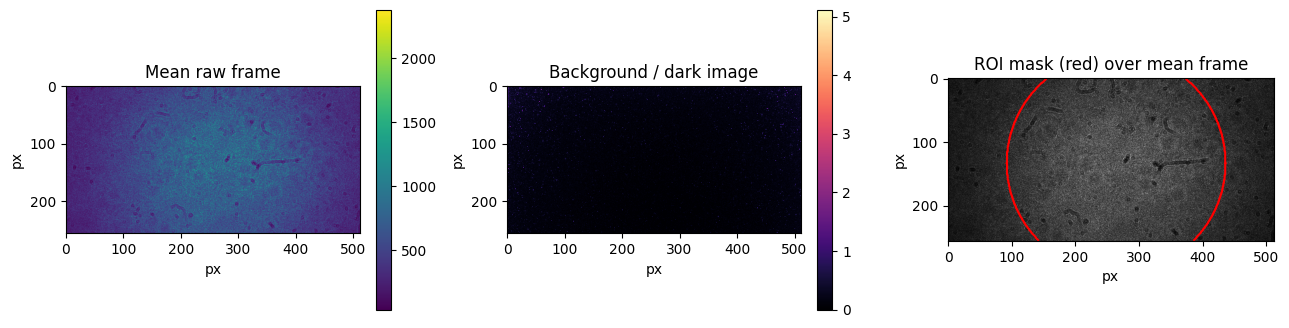

In [3]:
mean_frame = np.mean(image_data, axis=2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

im0 = axes[0].imshow(mean_frame, cmap="viridis")
axes[0].set_title("Mean raw frame")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(backgroundImg, cmap="magma")
axes[1].set_title("Background / dark image")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

axes[2].imshow(mean_frame, cmap="gray")
axes[2].contour(mask, colors="red", linewidths=1.5)
axes[2].set_title("ROI mask (red) over mean frame")

for ax in axes:
    ax.set_xlabel("px"); ax.set_ylabel("px")
plt.tight_layout()
plt.show()

## 3. Dark / read noise

`calculate_dark_noise` turns the dark (no-light) frames into a per-pixel, windowed
variance map (`darkVarPerWindow`). This is the noise floor that gets subtracted from every
measured frame before computing the speckle contrast — it should be small, spatially
smooth-ish, and independent of the illumination pattern.

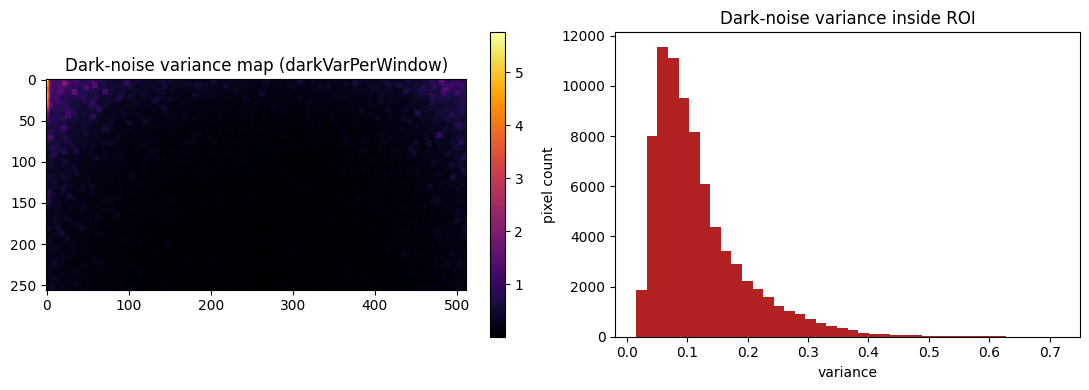

Mean dark-noise variance in ROI: 0.1193


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].imshow(darkVarPerWindow, cmap="inferno")
axes[0].set_title("Dark-noise variance map (darkVarPerWindow)")
plt.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].hist(darkVarPerWindow[mask].ravel(), bins=40, color="firebrick")
axes[1].set_title("Dark-noise variance inside ROI")
axes[1].set_xlabel("variance"); axes[1].set_ylabel("pixel count")

plt.tight_layout()
plt.show()

print(f"Mean dark-noise variance in ROI: {np.nanmean(darkVarPerWindow[mask]):.4f}")

## 4. Per-pixel noise budget for one example frame

`SCOS_Calculation` internally computes, for every frame: the local (windowed) mean and
raw variance, a shot-noise variance estimate, and a corrected variance
(`raw − dark − shot`). It only returns the frame-averaged summary numbers though — here we
reproduce the exact same per-pixel math for a single frame so you can *see* each noise
term as an image, side by side.

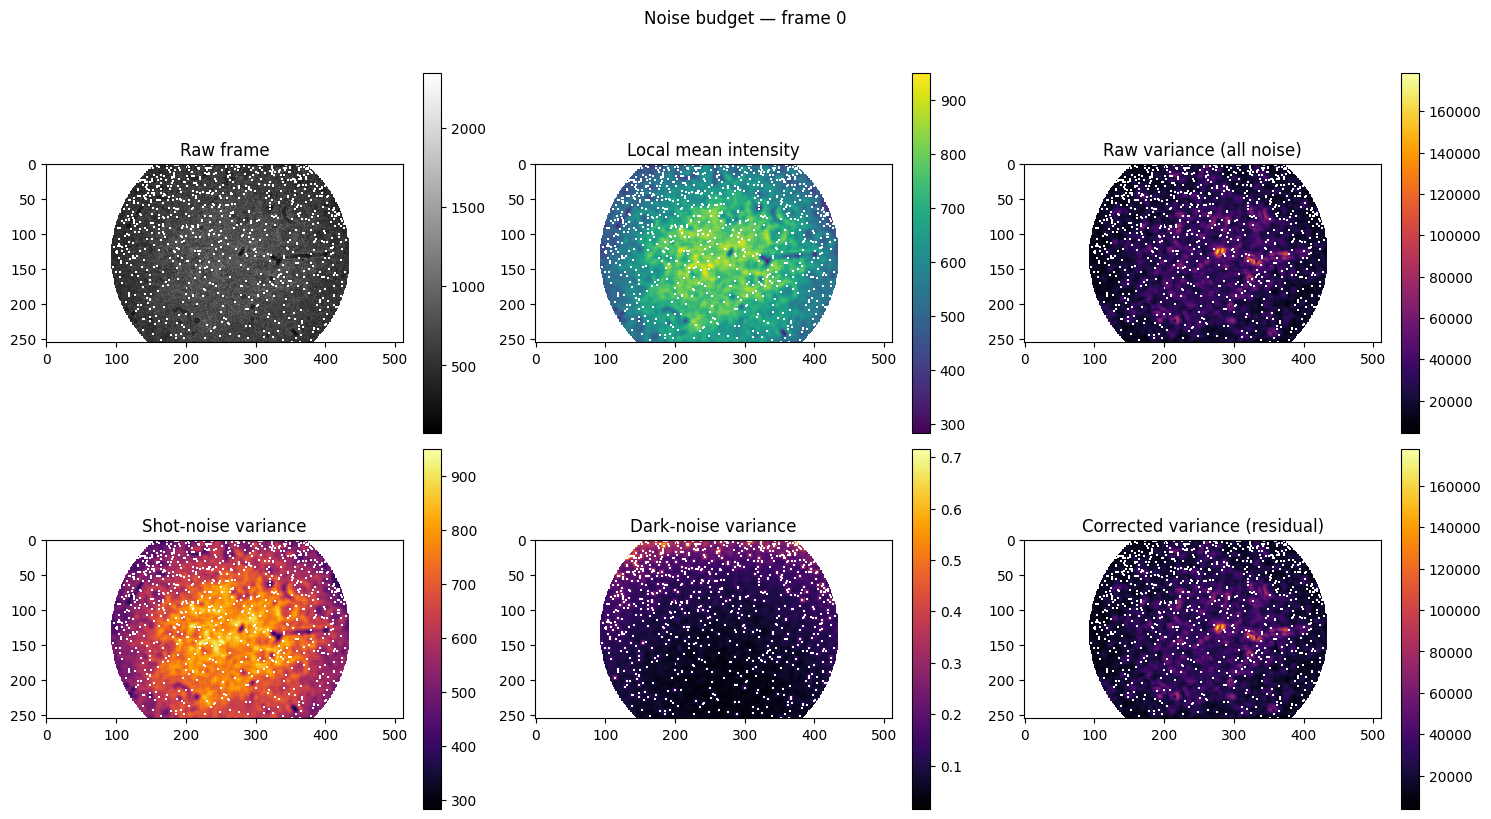

In [5]:
def noise_maps_for_frame(frame_idx, window_size=7):
    '''Reproduces the per-frame math inside SCOS_Calculation, but returns the
    intermediate 2D maps instead of just the ROI-averaged summary numbers.'''
    nBits = metadata["bit_depth"]
    is_pileup = metadata["is_pileup_correction"]
    black_level = metadata["black_level"]
    N_max = 2 ** nBits - 1

    roi_pixels = backgroundImg[mask]
    mean_dark, std_dark = np.nanmean(roi_pixels), np.nanstd(roi_pixels)
    good_pixel_mask = backgroundImg <= (mean_dark + 3 * std_dark)
    combined_mask = mask & good_pixel_mask

    M_float = combined_mask.astype(float)
    mask_weights = uniform_filter(M_float, size=window_size)
    mask_weights[mask_weights == 0] = np.nan

    im_raw = image_data[:, :, frame_idx].astype(float) - black_level
    Ic = im_raw - backgroundImg

    local_mean = uniform_filter(Ic * M_float, size=window_size) / mask_weights
    mean_im_sq = uniform_filter((Ic ** 2) * M_float, size=window_size) / mask_weights
    local_mean_raw = uniform_filter(im_raw * M_float, size=window_size) / mask_weights
    var_im = mean_im_sq - local_mean ** 2

    if is_pileup:
        correction_factor = 1.0
    else:
        correction_factor = np.maximum(1.0 - local_mean_raw / N_max, 0.0)
    shot_noise_var = local_mean_raw * correction_factor

    corrected_var = var_im - darkVarPerWindow - shot_noise_var

    return dict(im_raw=im_raw, local_mean=local_mean, var_im=var_im,
                shot_noise_var=shot_noise_var, corrected_var=corrected_var,
                mask=combined_mask)


EXAMPLE_FRAME = 0
maps = noise_maps_for_frame(EXAMPLE_FRAME)

panels = [
    ("Raw frame", maps["im_raw"], "gray"),
    ("Local mean intensity", maps["local_mean"], "viridis"),
    ("Raw variance (all noise)", maps["var_im"], "inferno"),
    ("Shot-noise variance", maps["shot_noise_var"], "inferno"),
    ("Dark-noise variance", darkVarPerWindow, "inferno"),
    ("Corrected variance (residual)", maps["corrected_var"], "inferno"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (title, data, cmap) in zip(axes.ravel(), panels):
    im = ax.imshow(np.where(maps["mask"], data, np.nan), cmap=cmap)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"Noise budget — frame {EXAMPLE_FRAME}", y=1.02)
plt.tight_layout()
plt.show()

## 5. Run the full SCOS calculation across all frames

Now run `SCOS_Calculation` (the same function `scos_analysis.py` calls) over the whole
stack to get the frame-by-frame contrast (`K2_raw`, `K2_corrected`) and blood-flow index
(`BFi`).

In [7]:
res = SCOS_Calculation(
    image_data=image_data,
    camera_gain=metadata["gain"],
    mask=mask,
    black_level=metadata["black_level"],
    frame_rate=metadata["frame_rate"],
    backgroundImg=backgroundImg,
    darkVarPerWindow=darkVarPerWindow,
    window_size=7,
    nBits=metadata["bit_depth"],
    is_pileup=metadata["is_pileup_correction"],
)

K2_raw = res["K2_raw"]
K2_corrected = res["K2_corrected"]
BFi = res["BFi"]
time_vector = res["time_vector"]

print(f"K2_raw:       mean={np.mean(K2_raw):.4f}  std={np.std(K2_raw):.4f}")
print(f"K2_corrected: mean={np.mean(K2_corrected):.4f}  std={np.std(K2_corrected):.4f}")
print(f"BFi:          mean={np.mean(BFi):.4f}  std={np.std(BFi):.4f}")

K2_raw:       mean=0.0641  std=0.0002
K2_corrected: mean=0.0626  std=0.0002
BFi:          mean=15.9814  std=0.0629


## 6. Noise decomposition over time

For every frame, `K2_raw` (total measured contrast) splits exactly into three pieces:

```
K2_raw  =  K2_dark  +  K2_shot  +  K2_corrected
           (dark)      (shot)     (signal + residual)
```

because the variance subtraction in `SCOS_Calculation` is linear. The stacked area plot
below shows how much of the total measured noise comes from each source, frame by frame —
and whether the "corrected" band (what's left after removing dark and shot noise) still
carries a real, structured signal instead of just being flat.

max |K2_raw - (dark + shot + corrected)| = 4.16e-17  (should be ~0)


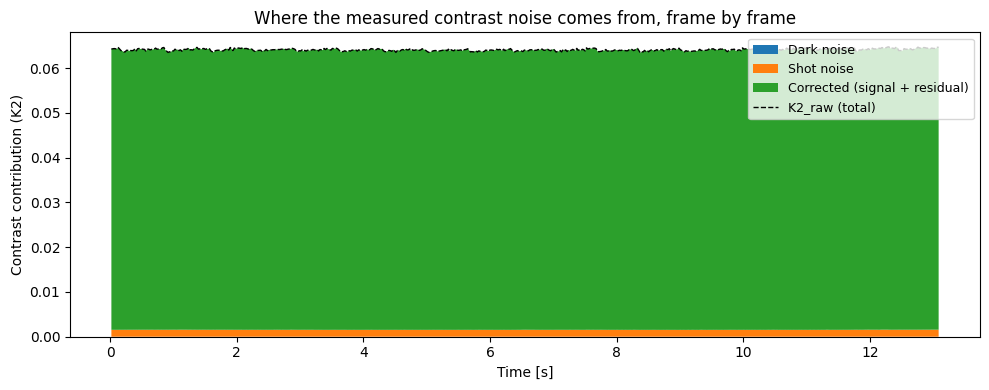

In [8]:
num_frames = image_data.shape[2]
combined_mask = maps["mask"]  # bad-pixel-filtered ROI mask, same for every frame

K2_dark_frac = np.zeros(num_frames)
K2_shot_frac = np.zeros(num_frames)

for f in range(num_frames):
    m = noise_maps_for_frame(f)
    meanFrame = np.nanmean(
        (image_data[:, :, f] - metadata["black_level"] - backgroundImg)[combined_mask]
    )
    meanFrame = meanFrame if meanFrame > 0 else 1e-5
    meanFrame_sq = meanFrame ** 2
    K2_dark_frac[f] = np.nanmean(darkVarPerWindow[combined_mask]) / meanFrame_sq
    K2_shot_frac[f] = np.nanmean(m["shot_noise_var"][combined_mask]) / meanFrame_sq

# sanity check: the three pieces should add back up to K2_raw
recon_error = np.nanmax(np.abs(K2_raw - (K2_dark_frac + K2_shot_frac + K2_corrected)))
print(f"max |K2_raw - (dark + shot + corrected)| = {recon_error:.2e}  (should be ~0)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.stackplot(
    time_vector, K2_dark_frac, K2_shot_frac, np.clip(K2_corrected, 0, None),
    labels=["Dark noise", "Shot noise", "Corrected (signal + residual)"],
    colors=["tab:blue", "tab:orange", "tab:green"],
)
ax.plot(time_vector, K2_raw, "k--", linewidth=1, label="K2_raw (total)")
ax.set_xlabel("Time [s]"); ax.set_ylabel("Contrast contribution (K2)")
ax.set_title("Where the measured contrast noise comes from, frame by frame")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## 7. K2_raw vs. K2_corrected vs. BFi over time

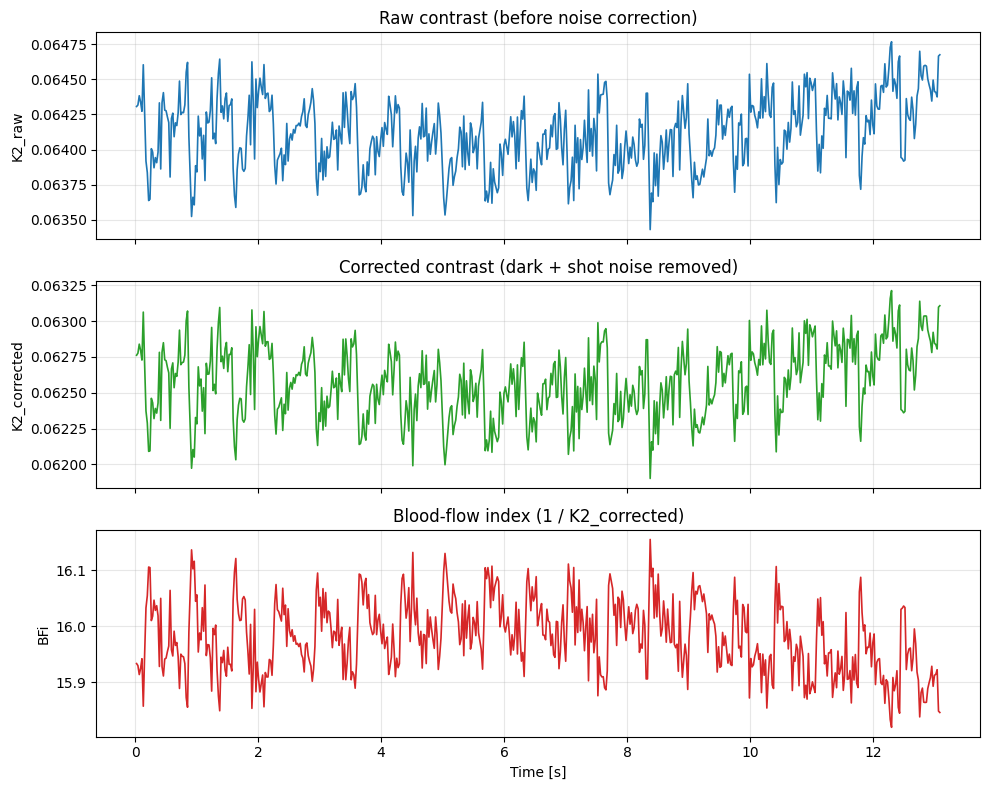

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(time_vector, K2_raw, color="tab:blue", linewidth=1.2)
axes[0].set_ylabel("K2_raw"); axes[0].set_title("Raw contrast (before noise correction)")

axes[1].plot(time_vector, K2_corrected, color="tab:green", linewidth=1.2)
axes[1].set_ylabel("K2_corrected"); axes[1].set_title("Corrected contrast (dark + shot noise removed)")

axes[2].plot(time_vector, BFi, color="tab:red", linewidth=1.2)
axes[2].set_ylabel("BFi"); axes[2].set_xlabel("Time [s]")
axes[2].set_title("Blood-flow index (1 / K2_corrected)")

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Is there a real signal above the noise floor?

`find_fft_peak` looks for a dominant frequency in the 0.5–2.5 Hz band (typical
pulsatile/flow range) and compares its magnitude to the surrounding noise floor. If
`K2_corrected` and `BFi` are dominated by noise, there won't be a clear peak — if the
correction worked, a pulsatile flow signal should stand out.

BFi: dominant frequency = 1.452 Hz  (87.1 BPM)  SNR = 11.51


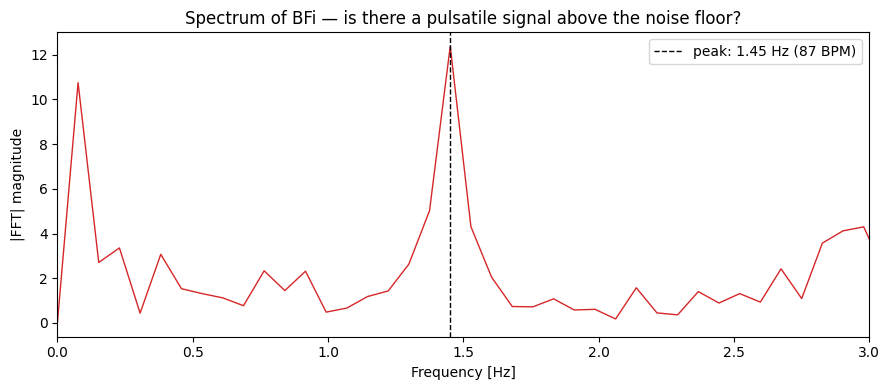

In [10]:
peak_freq, snr, mags, freqs = find_fft_peak(time_vector, BFi)
print(f"BFi: dominant frequency = {peak_freq:.3f} Hz  ({peak_freq * 60:.1f} BPM)  SNR = {snr:.2f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(freqs, mags, color="tab:red", linewidth=1)
if np.isfinite(peak_freq):
    ax.axvline(peak_freq, color="k", linestyle="--", linewidth=1,
               label=f"peak: {peak_freq:.2f} Hz ({peak_freq * 60:.0f} BPM)")
ax.set_xlim(0, 3)
ax.set_xlabel("Frequency [Hz]"); ax.set_ylabel("|FFT| magnitude")
ax.set_title("Spectrum of BFi — is there a pulsatile signal above the noise floor?")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Hot / bad pixel map

`SCOS_Calculation` flags "bad" pixels with a 3-sigma test on the background (dark) image:
any ROI pixel whose dark level is more than `mean + 3*std` above the rest of the ROI gets
excluded from every downstream calculation (`good_pixel_mask` inside the function). This
reproduces that exact test and shows which pixels get flagged, and how many.

Hot pixels flagged: 895 / 78992 ROI pixels (1.13%)


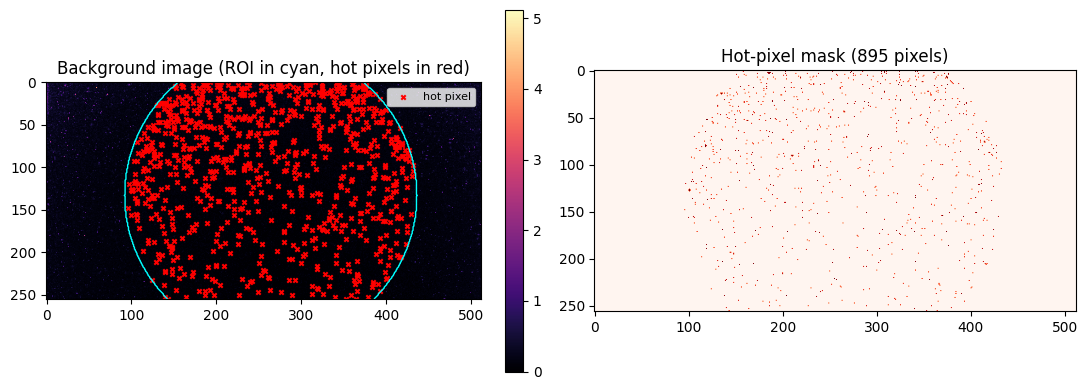

In [11]:
mean_dark = np.nanmean(backgroundImg[mask])
std_dark = np.nanstd(backgroundImg[mask])
hot_pixel_mask = mask & (backgroundImg > (mean_dark + 3 * std_dark))

n_hot = int(hot_pixel_mask.sum())
n_roi = int(mask.sum())
print(f"Hot pixels flagged: {n_hot} / {n_roi} ROI pixels ({100 * n_hot / n_roi:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im0 = axes[0].imshow(backgroundImg, cmap="magma")
axes[0].contour(mask, colors="cyan", linewidths=1)
ys, xs = np.where(hot_pixel_mask)
axes[0].scatter(xs, ys, s=10, c="red", marker="x", label="hot pixel")
axes[0].set_title("Background image (ROI in cyan, hot pixels in red)")
axes[0].legend(loc="upper right", fontsize=8)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

axes[1].imshow(hot_pixel_mask, cmap="Reds")
axes[1].set_title(f"Hot-pixel mask ({n_hot} pixels)")

plt.tight_layout()
plt.show()

## 10. 3D dark variance map (H × W × Var)

A 3D surface of the per-pixel **temporal variance** (variance of each pixel's intensity
across every frame in the stack, restricted to the ROI) makes spatial noise structure easy
to spot — e.g. a bump where illumination (and shot noise) is strongest, or streaks from
readout artifacts that a flat 2D heatmap can hide.

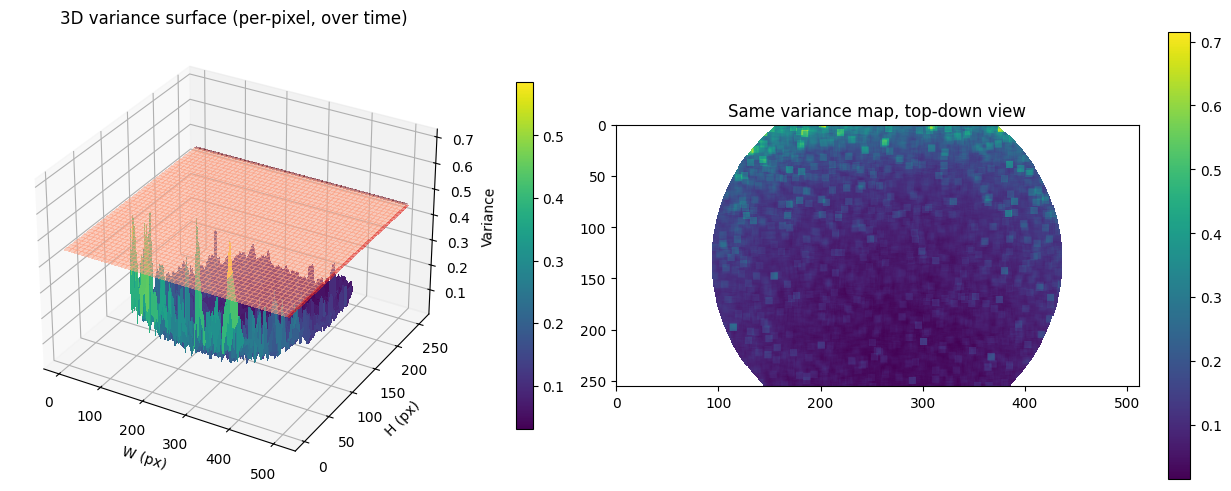

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3D projection)

temporal_var = darkVarPerWindow
temporal_var_roi = np.where(mask, temporal_var, np.nan)

hot_pixel_z= mean_dark + 3 * std_dark

H, W = temporal_var.shape
Y, X = np.mgrid[0:H, 0:W]

fig = plt.figure(figsize=(13, 5))

ax3d = fig.add_subplot(1, 2, 1, projection="3d")
surf = ax3d.plot_surface(X, Y, temporal_var_roi, cmap="viridis", linewidth=0, antialiased=False)
ax3d.set_xlabel("W (px)"); ax3d.set_ylabel("H (px)"); ax3d.set_zlabel("Variance")
ax3d.set_title("3D variance surface (per-pixel, over time)")
fig.colorbar(surf, ax=ax3d, fraction=0.03, pad=0.1)

ax2d = fig.add_subplot(1, 2, 2)
im = ax2d.imshow(temporal_var_roi, cmap="viridis")
ax2d.set_title("Same variance map, top-down view")
plt.colorbar(im, ax=ax2d, fraction=0.046)

plt.tight_layout()
plt.show()

## Notes

- **To use your own data**, just set `MEASUREMENT_DIR` in cell 2 to a real folder (a
  `SCOS_Scan_*` offset or a `ref-*/SCOS_Single_*` folder produced by your acquisition
  code / expected by `scos_analysis.py`) — everything else re-runs automatically.
- If `metadata.json` is missing, sensible defaults are used (`frame_rate=100 Hz`,
  `gain=1.0`, `bit_depth=8`, no pile-up correction) — edit them directly in the loaded
  `metadata` dict if needed before re-running the later cells.
- For a **CMOS** camera (not SPAD), swap `SCOS_Calculation` for `SCOS_Calculation_CMOS` in
  cell 11 — it takes the same arguments plus `mode` (`"frame"` or `"line"`).
- Once you're happy with a measurement, `scos_analysis.py` is the batch version of this
  same pipeline — it runs `SCOS_Calculation` over every `SCOS_Scan_*` / `SCOS_Single_*`
  folder under a base path and writes out `scos_analysis_results.csv`, which
  `scos_results_explorer.ipynb` then browses interactively.